# Attempt 2: Thematic Mapping (Thai Constitution)

เป้าหมาย: map ระดับมาตราแบบข้ามฉบับด้วยธีมเชิงเนื้อหา ไม่ยึด chapter title อย่างเดียว

In [1]:
%pip install pandas numpy scikit-learn pythainlp attacut bertopic transformers torch sentencepiece tqdm umap-learn hdbscan seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '../../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
print(f"Font loaded: {font_prop.get_name()}")

Font loaded: LINE Seed Sans TH


In [3]:
import re
import warnings
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from transformers import AutoTokenizer, AutoModel

from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
MODEL_NAME = 'airesearch/wangchanberta-base-att-spm-uncased'
MAX_LENGTH = 416
BATCH_SIZE = 16
print('Device:', DEVICE)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


/Users/natthawat/Desktop/code/Data-Modeling-Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


## 1) Load + preprocess

In [4]:
df = pd.read_csv('../../output/sections_v2.csv', encoding='utf-8-sig', engine='python', on_bad_lines='skip')
df = df.rename(columns={'doc_id': 'constitution_id'})
df['text'] = df['text'].fillna('').astype(str)
df = df[df['text'].str.strip().ne('')].copy().reset_index(drop=True)

GROUP_A_FUNCTION = [
    'ตาม', 'แห่ง', 'ว่าด้วย', 'ทั้งนี้', 'ดังกล่าว', 'ดังต่อไปนี้', 'อันเป็น',
    'โดย', 'ซึ่ง', 'อัน', 'ใน', 'แก่', 'ต่อ', 'จาก', 'ระหว่าง', 'เพื่อ',
    'มิ', 'ย่อม', 'ให้', 'แต่', 'หรือ', 'และ', 'รวมทั้ง', 'อีก', 'ทั้ง',
]
GROUP_B_STRUCTURE = [
    'มาตรา', 'หมวด', 'วรรค', 'ส่วน', 'บท', 'บัญญัติ', 'ฉบับ', 'พ.ศ.',
    'พุทธศักราช', 'รัฐธรรมนูญ', 'ราชอาณาจักรไทย', 'ประกาศ',
]
GROUP_C_NOISE = ['กฎหมาย', 'ระเบียบ', 'ภายใต้', 'กรณี', 'หน้าที่', 'ใด', 'ท่าน', 'บังคับ', 'พระ', 'บรรดา']
custom_stopwords = sorted(set(thai_stopwords()) | set(GROUP_A_FUNCTION) | set(GROUP_B_STRUCTURE) | set(GROUP_C_NOISE))
stopword_set = set(custom_stopwords)

def preprocess_thai(text: str) -> list[str]:
    toks = word_tokenize(text, engine='attacut')
    return [t.strip() for t in toks if t.strip() and t.strip() not in stopword_set and not re.match(r'^[\W_]+$', t.strip())]

tqdm.pandas(desc='Tokenizing')
df['tokens'] = df['text'].progress_apply(preprocess_thai)
df['joined_tokens'] = df['tokens'].apply(lambda xs: ' '.join(xs))
print('sections:', len(df), 'constitutions:', df['constitution_id'].nunique())


Tokenizing: 100%|██████████| 2797/2797 [00:13<00:00, 210.97it/s]

sections: 2797 constitutions: 38


## 2) Theme seeds (taxonomy + flexible extra)

In [5]:
THEME_SEEDS = {
    'ทั่วไป/โครงสร้าง': ['บททั่วไป', 'บทสุดท้าย', 'บทเฉพาะกาล', 'แก้ไขเพิ่มเติม'],
    'สถาบันพระมหากษัตริย์': ['พระมหากษัตริย์', 'สืบราชสมบัติ', 'องคมนตรี', 'ผู้สำเร็จราชการ'],
    'สิทธิ-เสรีภาพ-หน้าที่': ['สิทธิ', 'เสรีภาพ', 'หน้าที่', 'ปวงชน', 'ชนชาวไทย'],
    'แนวนโยบายแห่งรัฐ': ['แนวนโยบาย', 'พื้นฐานแห่งรัฐ', 'รัฐ'],
    'นิติบัญญัติ': ['รัฐสภา', 'สภาผู้แทนราษฎร', 'วุฒิสภา', 'ตรากฎหมาย'],
    'บริหาร': ['คณะรัฐมนตรี', 'นายกรัฐมนตรี', 'รัฐมนตรี', 'บริหาร'],
    'ตุลาการ': ['ศาล', 'ศาลยุติธรรม', 'ศาลปกครอง', 'ศาลรัฐธรรมนูญ'],
    'องค์กรอิสระ/องค์กรตามรัฐธรรมนูญ': ['กกต', 'ป.ป.ช.', 'ผู้ตรวจการแผ่นดิน', 'สตง', 'กสม'],
    'ตรวจสอบอำนาจรัฐ/ต้านทุจริต': ['ตรวจสอบ', 'ผลประโยชน์', 'บัญชีทรัพย์สิน', 'ถอดถอน', 'ทุจริต'],
    'การคลังและงบประมาณ': ['การคลัง', 'งบประมาณ', 'เงินแผ่นดิน', 'ตรวจเงินแผ่นดิน'],
    'ท้องถิ่น': ['ท้องถิ่น', 'ปกครองส่วนท้องถิ่น'],
    'การมีส่วนร่วมทางการเมือง': ['ประชามติ', 'มีส่วนร่วม', 'เข้าชื่อเสนอ', 'ลงคะแนนโดยตรง'],
    'ปฏิรูปประเทศ': ['ปฏิรูปประเทศ'],
    'จริยธรรมทางการเมือง': ['จริยธรรม', 'มาตรฐาน', 'ผู้ดำรงตำแหน่งทางการเมือง'],
}
seed_topic_list = [v for v in THEME_SEEDS.values()]
print('seed themes:', len(seed_topic_list))


seed themes: 14


## 3) Embedding

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

@torch.no_grad()
def embed_batch(texts: list[str]) -> np.ndarray:
    enc = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt').to(DEVICE)
    out = model(**enc).last_hidden_state
    mask = enc['attention_mask'].unsqueeze(-1).float()
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
    pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
    return pooled.cpu().numpy().astype('float32')

def embed_corpus(texts, batch_size=BATCH_SIZE):
    chunks=[]
    for i in tqdm(range(0, len(texts), batch_size), desc='Embedding'):
        chunks.append(embed_batch(texts[i:i+batch_size]))
    return np.vstack(chunks)

embeddings = embed_corpus(df['text'].tolist())
print('embeddings:', embeddings.shape)


2026-05-06:13:10:13 WARNING  [huggingface_hub.utils._http:904] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8154.07it/s]
[transformers] CamembertModel LOAD REPORT from: airesearch/wangchanberta-base-att-spm-uncased
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embedding: 100%|██████████| 175/175 [03:42<00:00,  1.27s/it]

embeddings: (2797, 768)


## 4) Guided BERTopic

In [7]:
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=RANDOM_STATE)
hdbscan_model = HDBSCAN(min_cluster_size=12, min_samples=3, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(token_pattern=r'[฀-๿]+', lowercase=False, min_df=2, stop_words=custom_stopwords)

topic_model = BERTopic(
    language='multilingual',
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,
    calculate_probabilities=False,
    verbose=True,
)

topics, _ = topic_model.fit_transform(df['joined_tokens'].tolist(), embeddings=embeddings)
df['topic'] = topics
topic_info = topic_model.get_topic_info()
print('n topics excl -1:', (topic_info['Topic'] != -1).sum())


2026-05-06 13:13:57,034 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-06 13:14:14,899 - BERTopic - Dimensionality - Completed ✓
2026-05-06 13:14:14,900 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-06 13:14:14,964 - BERTopic - Cluster - Completed ✓
2026-05-06 13:14:14,967 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 13:14:15,037 - BERTopic - Representation - Completed ✓


n topics excl -1: 101


## 5) Topic -> Theme mapping (allow extra)

In [8]:
def topic_repr(topic_id, n=15):
    return ' '.join([w for w, _ in (topic_model.get_topic(topic_id) or [])[:n]])

def theme_match_scores(repr_text: str):
    out = {}
    for theme, kws in THEME_SEEDS.items():
        out[theme] = sum(1 for kw in kws if kw in repr_text)
    return out

topic_rows = []
for t in topic_info['Topic'].tolist():
    if t == -1:
        continue
    rep = topic_repr(t)
    scores = theme_match_scores(rep)
    best_theme = max(scores, key=scores.get)
    best_score = scores[best_theme]
    assigned = best_theme if best_score > 0 else 'อื่น ๆ (emergent)'
    topic_rows.append({'topic': t, 'topic_repr': rep, 'assigned_theme': assigned, 'theme_match_score': best_score})

topic_theme_map = pd.DataFrame(topic_rows)
df = df.merge(topic_theme_map[['topic', 'assigned_theme']], on='topic', how='left')
topic_theme_map.head(10)


,topic,topic_repr,assigned_theme,theme_match_score
0,0,ศาลฎีกา ผู้ดํารงตําแหน่ง ไต่สวน ยื่น อัยการ กล...,ตุลาการ,1
1,1,สิทธิ เจ้าพนักงาน ท้องถิ่น เรื่องราว ทุกข์ วิธ...,สิทธิ-เสรีภาพ-หน้าที่,1
2,2,ว่าง แทน อายุ สภาผู้แทนราษฎร ร้อย ตำแหน่ง สมาช...,นิติบัญญัติ,1
3,3,วินิจฉัย คณะตุลาการรัฐธรรมนูญ ร้อง แย้ง ข้อควา...,ตุลาการ,2
4,4,สรรหา กรรมการ เงินแผ่นดิน เลือก คน ตรวจ คัดเลื...,ตุลาการ,1
5,5,สนอง ประเภท ธรรมนูญ พิบูลสงคราม พระบรมราชโองกา...,อื่น ๆ (emergent),0
6,6,จอมทัพ เคารพ ละเมิด ดำรง ฐานะ ไทย กำเนิด เสมอ ...,สถาบันพระมหากษัตริย์,1
7,7,คุก ตาย ลา ห้าม ลักษณะ ประมาท คุณสมบัติ โทษ สิ...,อื่น ๆ (emergent),0
8,8,พระองค์ สำเร็จ องคมนตรี แทน สําเร็จ ราชการ ชั่...,สถาบันพระมหากษัตริย์,1
9,9,ศาลปกครอง ศาลยุติธรรม เลื่อน ตุลาการ กรรมการ ศ...,ตุลาการ,3


## 6) Section-level soft theme scoring

In [9]:
# soft score: section gets score to all themes by token overlap against theme lexicon

theme_lexicon = {k: set(v) for k, v in THEME_SEEDS.items()}
all_themes = list(theme_lexicon.keys())

records = []
for _, r in df.iterrows():
    toks = set(r['tokens'])
    if not toks:
        continue
    per_theme = {}
    for th in all_themes:
        overlap = len(toks & theme_lexicon[th])
        per_theme[th] = overlap / max(1, len(theme_lexicon[th]))

    total = sum(per_theme.values())
    if total == 0:
        # allow emergent bucket when no seed evidence
        records.append({
            'section_id': r['section_id'], 'constitution_id': r['constitution_id'], 'year_th': r['year_th'],
            'topic': r['topic'], 'theme': 'อื่น ๆ (emergent)', 'theme_score': 1.0,
        })
    else:
        for th, sc in per_theme.items():
            if sc > 0:
                records.append({
                    'section_id': r['section_id'], 'constitution_id': r['constitution_id'], 'year_th': r['year_th'],
                    'topic': r['topic'], 'theme': th, 'theme_score': sc / total,
                })

section_theme_scores = pd.DataFrame(records)
section_theme_scores.head(10)


,section_id,constitution_id,year_th,topic,theme,theme_score
0,const_2475_s_1,const_2475,2475,6,อื่น ๆ (emergent),1.000000
1,const_2475_s_2,const_2475,2475,70,สถาบันพระมหากษัตริย์,1.000000
2,const_2475_s_3,const_2475,2475,6,สถาบันพระมหากษัตริย์,1.000000
3,const_2475_s_4,const_2475,2475,-1,สถาบันพระมหากษัตริย์,1.000000
4,const_2475_s_5,const_2475,2475,6,สถาบันพระมหากษัตริย์,1.000000
5,const_2475_s_6,const_2475,2475,56,สถาบันพระมหากษัตริย์,0.500000
6,const_2475_s_6,const_2475,2475,56,นิติบัญญัติ,0.500000
7,const_2475_s_7,const_2475,2475,76,สถาบันพระมหากษัตริย์,0.333333
8,const_2475_s_7,const_2475,2475,76,บริหาร,0.666667
9,const_2475_s_8,const_2475,2475,76,สถาบันพระมหากษัตริย์,0.500000


## 7) Stable Core summary

In [10]:
stable = (
    section_theme_scores
    .groupby('theme')
    .agg(
        n_sections=('section_id', 'nunique'),
        n_constitutions=('constitution_id', 'nunique'),
        avg_theme_score=('theme_score', 'mean'),
    )
    .reset_index()
)
stable['coverage_ratio'] = stable['n_constitutions'] / df['constitution_id'].nunique()
stable['stable_score'] = 0.7 * stable['coverage_ratio'] + 0.3 * stable['avg_theme_score']
stable = stable.sort_values('stable_score', ascending=False).reset_index(drop=True)
stable.head(15)


,theme,n_sections,n_constitutions,avg_theme_score,coverage_ratio,stable_score
0,อื่น ๆ (emergent),403,37,1.000000,0.973684,0.981579
1,บริหาร,690,38,0.475733,1.000000,0.842720
2,นิติบัญญัติ,1203,31,0.633934,0.815789,0.761233
3,สถาบันพระมหากษัตริย์,653,26,0.603491,0.684211,0.659995
4,สิทธิ-เสรีภาพ-หน้าที่,566,26,0.485172,0.684211,0.624499
5,ตุลาการ,339,22,0.521724,0.578947,0.561780
6,แนวนโยบายแห่งรัฐ,459,21,0.566912,0.552632,0.556916
7,ตรวจสอบอำนาจรัฐ/ต้านทุจริต,129,13,0.294392,0.342105,0.327791
8,ท้องถิ่น,163,10,0.465830,0.263158,0.323960
9,จริยธรรมทางการเมือง,54,7,0.435788,0.184211,0.259684


## 8) Dynamic summary

In [11]:
tmp = section_theme_scores.copy()
q1 = np.percentile(tmp['year_th'], 35)
q2 = np.percentile(tmp['year_th'], 65)

first = tmp[tmp['year_th'] <= q1].groupby('theme')['theme_score'].sum()
last = tmp[tmp['year_th'] >= q2].groupby('theme')['theme_score'].sum()

dyn = pd.concat([first.rename('first_mass'), last.rename('last_mass')], axis=1).fillna(0.0).reset_index()
dyn['first_ratio'] = dyn['first_mass'] / max(dyn['first_mass'].sum(), 1e-9)
dyn['last_ratio'] = dyn['last_mass'] / max(dyn['last_mass'].sum(), 1e-9)
dyn['trend_delta'] = dyn['last_ratio'] - dyn['first_ratio']
dyn['dynamic_score'] = dyn['trend_delta'].abs()
dyn = dyn.sort_values('dynamic_score', ascending=False).reset_index(drop=True)
dyn.head(15)


,theme,first_mass,last_mass,first_ratio,last_ratio,trend_delta,dynamic_score
0,อื่น ๆ (emergent),246.000000,77.000000,0.197273,0.074830,-0.122444,0.122444
1,สถาบันพระมหากษัตริย์,221.557917,116.484616,0.177673,0.113202,-0.064471,0.064471
2,ตุลาการ,55.464743,98.220792,0.044479,0.095453,0.050974,0.050974
3,แนวนโยบายแห่งรัฐ,92.407790,109.921420,0.074104,0.106824,0.032719,0.032719
4,ท้องถิ่น,15.132357,46.010067,0.012135,0.044713,0.032578,0.032578
5,สิทธิ-เสรีภาพ-หน้าที่,110.561368,110.852044,0.088662,0.107728,0.019066,0.019066
6,จริยธรรมทางการเมือง,1.000000,18.043913,0.000802,0.017535,0.016733,0.016733
7,ตรวจสอบอำนาจรัฐ/ต้านทุจริต,11.311574,25.546844,0.009071,0.024827,0.015756,0.015756
8,การคลังและงบประมาณ,1.944710,13.975063,0.001560,0.013581,0.012022,0.012022
9,บริหาร,148.337352,128.125536,0.118955,0.124515,0.005559,0.005559


## 9) Save outputs

In [12]:
section_theme_scores.to_csv('section_theme_scores.csv', index=False, encoding='utf-8-sig')
stable.to_csv('theme_stable_summary.csv', index=False, encoding='utf-8-sig')
dyn.to_csv('theme_dynamic_summary.csv', index=False, encoding='utf-8-sig')
topic_theme_map.to_csv('topic_theme_map.csv', index=False, encoding='utf-8-sig')

print('Saved:')
print(' - section_theme_scores.csv')
print(' - theme_stable_summary.csv')
print(' - theme_dynamic_summary.csv')
print(' - topic_theme_map.csv')


Saved:
 - section_theme_scores.csv
 - theme_stable_summary.csv
 - theme_dynamic_summary.csv
 - topic_theme_map.csv


## 10) Report Charts

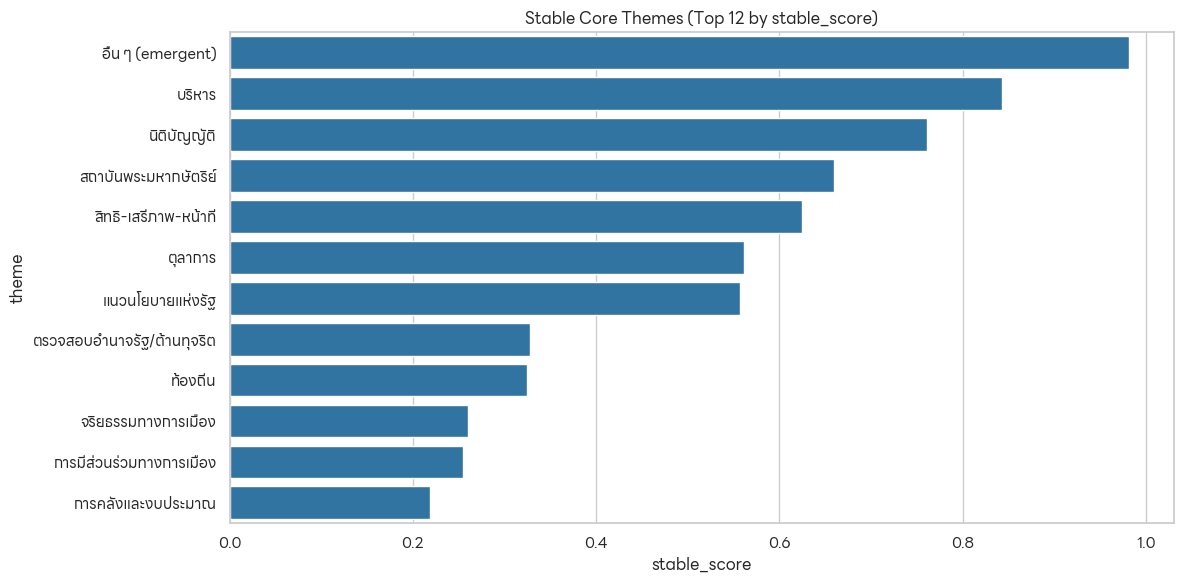

In [21]:
# Stable core: top themes
stable_top = stable.head(12).copy()
plt.figure(figsize=(12,6))
sns.barplot(data=stable_top, y='theme', x='stable_score', color='#1f77b4')
plt.title('Stable Core Themes (Top 12 by stable_score)')
plt.xlabel('stable_score')
plt.ylabel('theme')
plt.tight_layout()
plt.show()


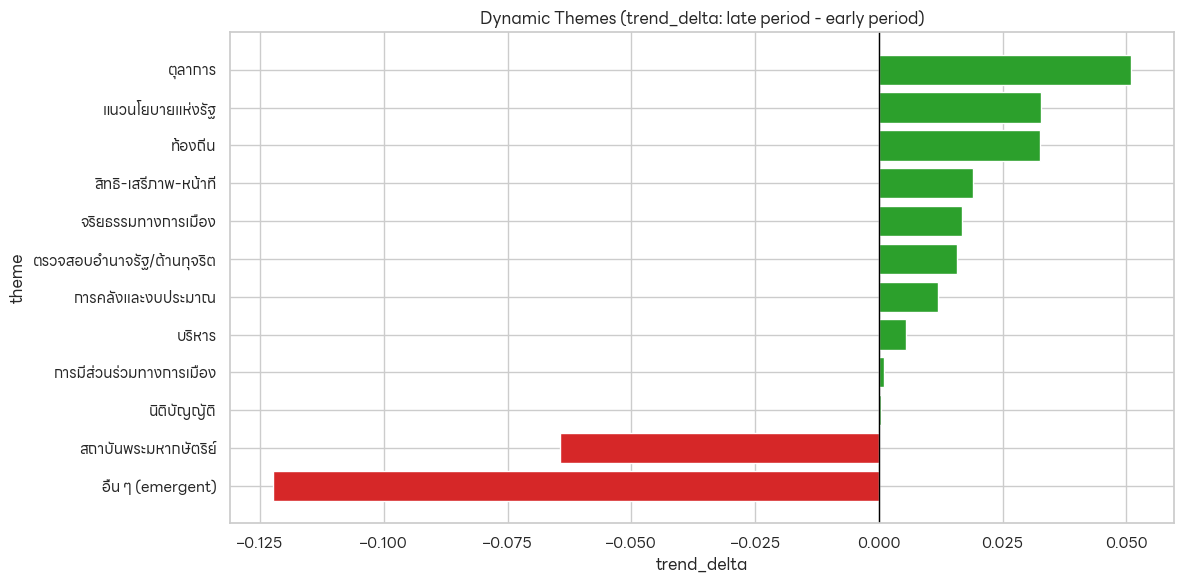

In [22]:
# Dynamic themes: strongest shifts across periods
dyn_top = dyn.head(12).copy()
dyn_top = dyn_top.sort_values('trend_delta')
plt.figure(figsize=(12,6))
colors = ['#d62728' if x < 0 else '#2ca02c' for x in dyn_top['trend_delta']]
plt.barh(dyn_top['theme'], dyn_top['trend_delta'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Dynamic Themes (trend_delta: late period - early period)')
plt.xlabel('trend_delta')
plt.ylabel('theme')
plt.tight_layout()
plt.show()


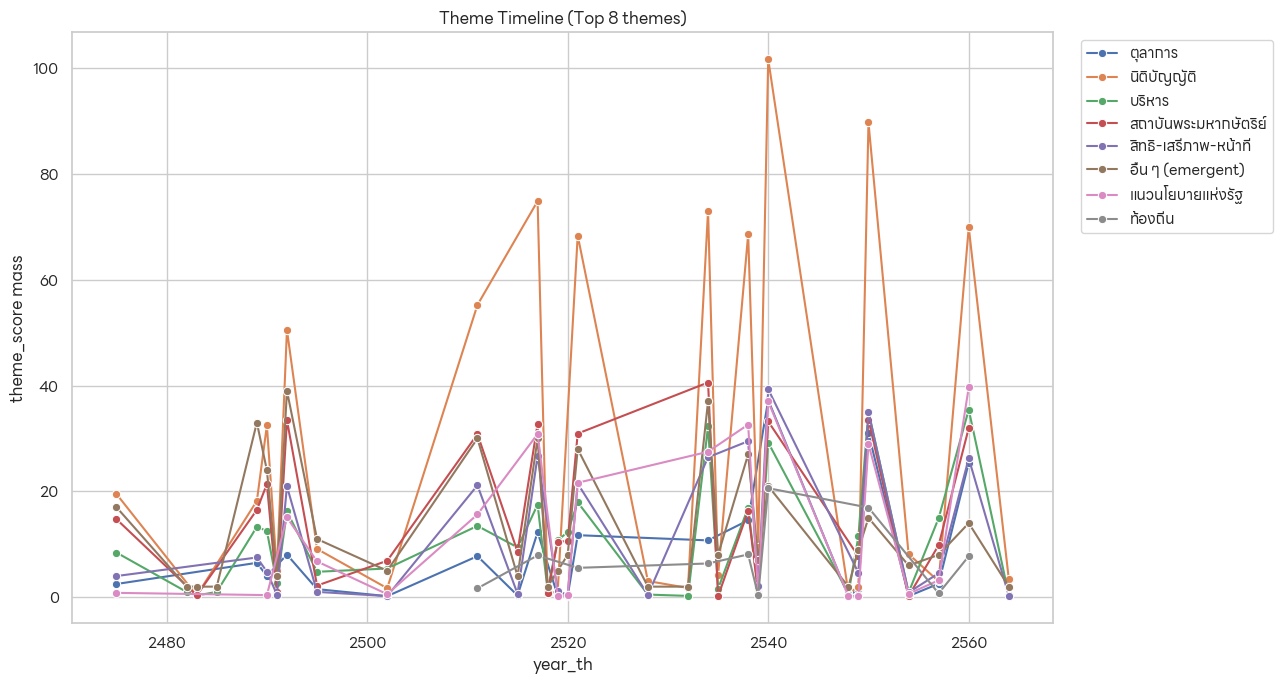

In [23]:
# Theme timeline (mass by year)
timeline = (
    section_theme_scores
    .groupby(['year_th', 'theme'], as_index=False)['theme_score']
    .sum()
)

# keep top 8 themes by total mass for readability
top_themes = (
    timeline.groupby('theme', as_index=False)['theme_score']
    .sum()
    .sort_values('theme_score', ascending=False)
    .head(8)['theme']
    .tolist()
)

time_small = timeline[timeline['theme'].isin(top_themes)].copy()

plt.figure(figsize=(13,7))
sns.lineplot(data=time_small, x='year_th', y='theme_score', hue='theme', marker='o')
plt.title('Theme Timeline (Top 8 themes)')
plt.xlabel('year_th')
plt.ylabel('theme_score mass')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 11) Conflict Map (co-occurrence on same section)

In [24]:
# Build conflict-like edges from co-occurring high theme scores in same section
pivot = section_theme_scores.pivot_table(
    index='section_id', columns='theme', values='theme_score', aggfunc='sum', fill_value=0.0
)

# only consider strong memberships to reduce noise
active = (pivot >= 0.35).astype(int)
themes = active.columns.tolist()

edges = []
for i in range(len(themes)):
    for j in range(i+1, len(themes)):
        a, b = themes[i], themes[j]
        w = int(((active[a] == 1) & (active[b] == 1)).sum())
        if w > 0:
            edges.append({'source_theme': a, 'target_theme': b, 'weight': w})

conflict_edges = pd.DataFrame(edges).sort_values('weight', ascending=False).reset_index(drop=True)
conflict_edges.head(20)


,source_theme,target_theme,weight
0,นิติบัญญัติ,สถาบันพระมหากษัตริย์,120
1,นิติบัญญัติ,บริหาร,102
2,สิทธิ-เสรีภาพ-หน้าที่,แนวนโยบายแห่งรัฐ,82
3,นิติบัญญัติ,สิทธิ-เสรีภาพ-หน้าที่,43
4,บริหาร,สถาบันพระมหากษัตริย์,43
5,ตุลาการ,สิทธิ-เสรีภาพ-หน้าที่,33
6,ตุลาการ,สถาบันพระมหากษัตริย์,24
7,ตุลาการ,นิติบัญญัติ,24
8,บริหาร,สิทธิ-เสรีภาพ-หน้าที่,17
9,สถาบันพระมหากษัตริย์,แนวนโยบายแห่งรัฐ,13


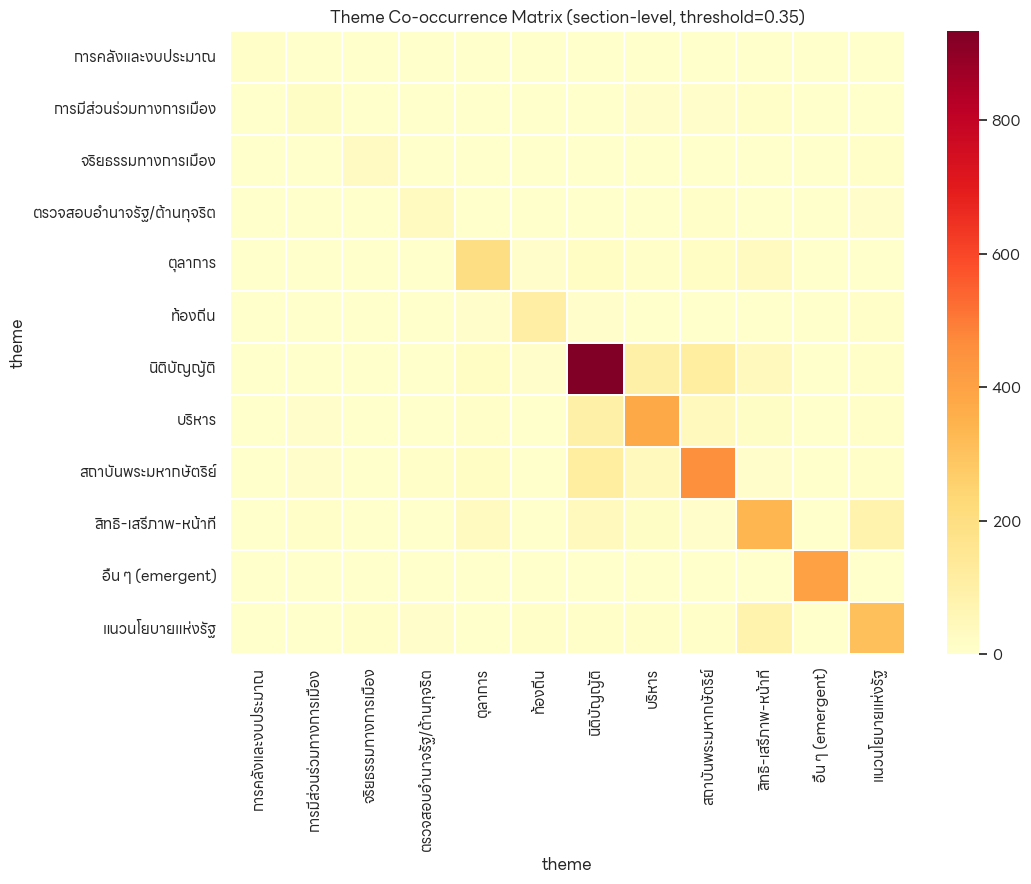

In [26]:
# Heatmap view of theme co-occurrence
co_mat = active.T.dot(active)

plt.figure(figsize=(11,9))
sns.heatmap(co_mat, cmap='YlOrRd', linewidths=0.3)
plt.title('Theme Co-occurrence Matrix (section-level, threshold=0.35)')
plt.tight_layout()
plt.show()


In [18]:
# Save chart-ready tables
timeline.to_csv('theme_timeline_mass.csv', index=False, encoding='utf-8-sig')
conflict_edges.to_csv('conflict_edges.csv', index=False, encoding='utf-8-sig')

print('Saved:')
print(' - theme_timeline_mass.csv')
print(' - conflict_edges.csv')


Saved:
 - theme_timeline_mass.csv
 - conflict_edges.csv
